실습 1. 상관관계 heatmap 해석하기
- 여러 센서의 상관을 색으로 그려 관계 파악

목표
- 여러 센서의 상관 heatmap을 그려 함께 움직이는 센서를 색으로 파악

단계
- 다섯 센서의 상관행렬을 계산
- 히트맵으로 색과 숫자를 함께 표시
- 대각선을 빼고 진한 칸을 강한 관계로 읽기

예상 결과
- 진한 칸이 강한 양·음 상관, s_2와 s_4가 가장 진함

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/21_cmapss_fd001_sample.csv')
print(df.shape)

sensors = ['s_2', 's_3', 's_4', 's_7', 's_11']

(1031, 10)


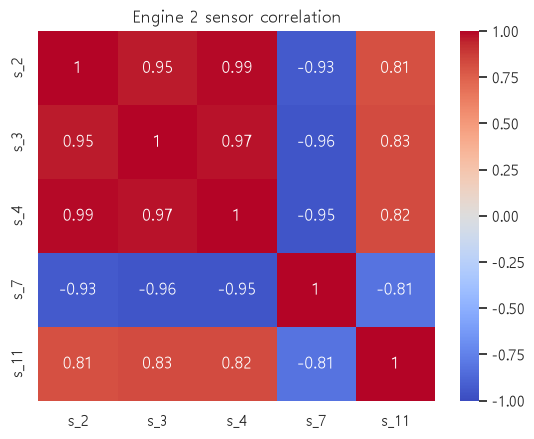

In [5]:
# [2번 엔진의 주요 센서 간 상관관계 행렬 시각화]
# 1. sns.heatmap(): 2번 엔진 센서 간 상관관계의 크기를 색상 강도로 매핑하고, 수치 값을 셀에 오버레이합니다.
# 2. vmin=-1, vmax=1: 색상 범위를 피어슨 상관계수 한계치인 -1(완벽한 음)부터 +1(완벽한 양)로 제한하여 왜곡을 없앱니다.
# * 어떤 센서들이 서로 완전히 똑같이 행동하는지(예: s_2와 s_4가 약 0.99로 극도의 양의 상관),
#   어떤 센서가 서로 상반되는 움직임을 띄는지 파악하여 향후 고장 모델 입력 피처 선택의 우선순위를 결정합니다.
# * 히트맵을 렌더링하고 `plt.close()`를 수행해야 다음 실습 도화지와 격리되어 이미지가 혼선 없이 깔끔하게 저장됩니다.

eng_02 = df[df['unit_nr'] == 2].reset_index(drop=True)
sns.heatmap(eng_02[sensors].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Engine 2 sensor correlation')
plt.show()